<a href="https://colab.research.google.com/github/hye0-n0/hye0-n0/blob/main/stat_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
price= pd.read_csv('/Users/hye0n0/통계/고등어/price.csv')

In [ ]:
test= pd.read_csv('/Users/hye0n0/통계/고등어/ts_test.csv')

In [ ]:
test['Unnamed: 0']=pd.to_datetime(test['Unnamed: 0'])

In [ ]:
test=test.set_index(test['Unnamed: 0'])

In [ ]:
test=test.drop(columns='Unnamed: 0')

In [ ]:
test

,0
Unnamed: 0,
2022-01-01,3494.000000
2022-02-01,3739.000000
2022-03-01,3858.000000
2022-04-01,4542.540984
2022-05-01,5205.000000
2022-06-01,4778.000000
2022-07-01,3805.000000


In [ ]:
test =  test.interpolate(method='time')

In [ ]:
i= pd.read_csv('/Users/hye0n0/통계/고등어/기준금리데이터.csv')

In [ ]:
i = i.T
i

,0
Unnamed: 0,기준금리
2014\r\n01월,2.5
2014\r\n02월,2.5
2014\r\n03월,2.5
2014\r\n04월,2.5
...,...
2022\r\n03월,1.25
2022\r\n04월,1.5
2022\r\n05월,1.75
2022\r\n06월,1.75


In [ ]:
i_tr=i.iloc[1:97,0:]

In [ ]:
month = [i for i in range(14,22)]

In [ ]:
i_tr=i_tr.set_index(price['Unnamed: 0'])

In [ ]:
i_tr

,0
Unnamed: 0,
2014-01-01,2.5
2014-02-01,2.5
2014-03-01,2.5
2014-04-01,2.5
2014-05-01,2.5
...,...
2021-08-01,0.75
2021-09-01,0.75
2021-10-01,0.75


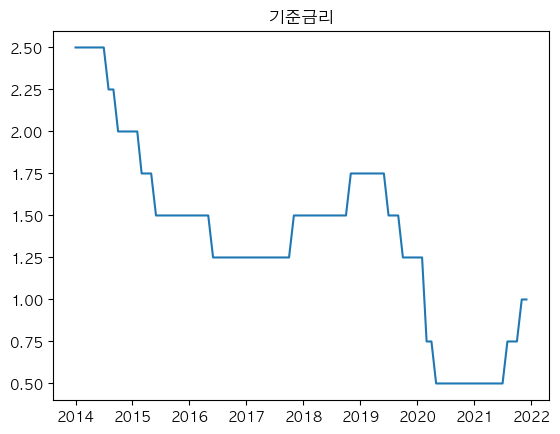

In [ ]:
plt.title('기준금리')
plt.plot(i_tr.index, i_tr[0])

In [ ]:
np.corr(i_tr[0], price['price'])

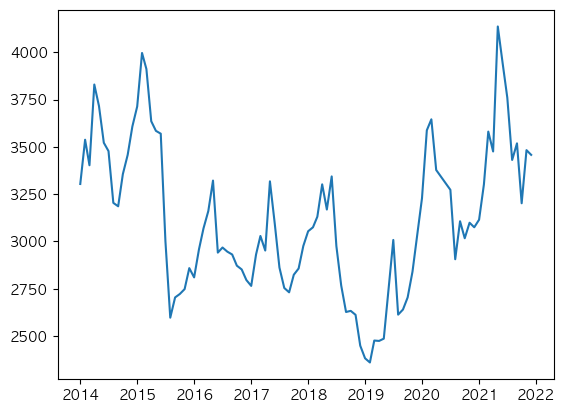

In [ ]:
plt.plot(i_tr.index, price['price'])

In [ ]:
price['dwh'][price['평균유의파고'] > 0.709] = 1

In [ ]:
price.to_csv('/Users/hye0n0/통계/고등어/price.csv')

In [ ]:
df=price[['Unnamed: 0','price', 'dwh', 'dwt', 't']]

In [ ]:
x=np.diff(price['price'])

Text(0.5, 1.0, '1차 차분한 신선고등어 가격')

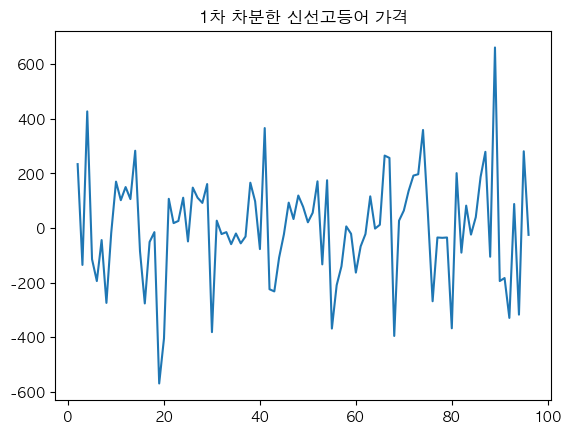

In [ ]:
plt.plot(df['t'][1:], np.diff(price['price']))
plt.title('1차 차분한 신선고등어 가격' )

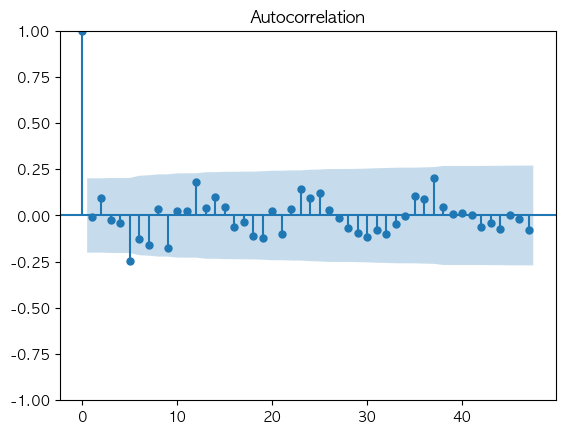

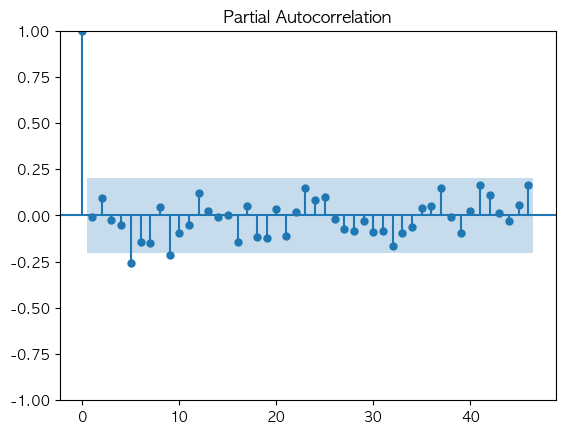

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(x, lags=47)
plot_pacf(x, lags=46)
plt.show()

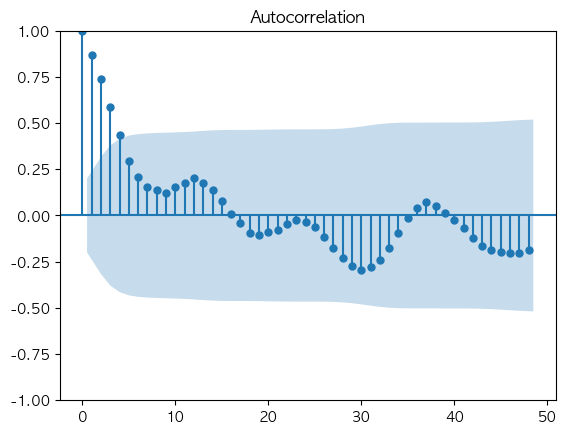

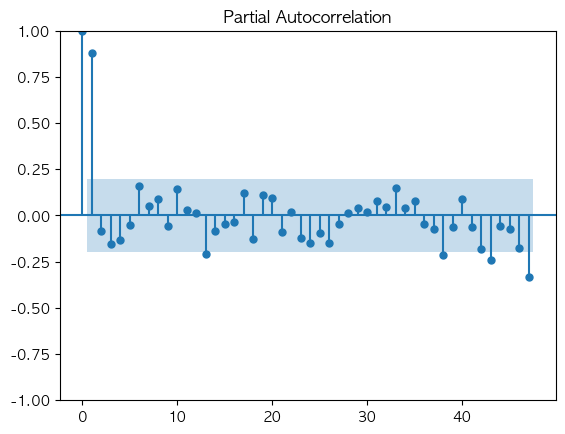

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(price['price'], lags=48)
plot_pacf(price['price'], lags=47)
plt.show()

In [ ]:
# pip install pmdarima
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pmdarima.arima import ndiffs
import pmdarima as pm

In [ ]:
kpss_diffs = ndiffs(price['price'], alpha=0.05, test='kpss', max_d=6)
adf_diffs = ndiffs(price['price'], alpha=0.05, test='adf', max_d=6)
n_diffs = max(adf_diffs, kpss_diffs)

print(f"추정된 차수 d = {n_diffs}")

추정된 차수 d = 1


In [ ]:
p = np.diff(price['price'])

In [ ]:
model = pm.auto_arima(y = price['price']        # 데이터
                      , d = 1          # 차분 차수, ndiffs 결과!
                      , start_p = 0
                      , max_p = 10
                      , start_q = 0
                      , max_q = 10
                      , m = 12
                      , seasonal = True # 계절성 ARIMA가 아니라면 필수!
                      , stepwise = True
                      , trace=True
                      )

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1278.448, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1278.006, Time=0.10 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1278.780, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1276.454, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1276.023, Time=0.04 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=1277.148, Time=0.13 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1276.781, Time=0.07 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=0.47 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1278.008, Time=0.09 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=1278.556, Time=0.18 sec
 ARIMA(0,1,0)(1,0,0)[12]             : AIC=1274.041, Time=0.03 sec
 ARIMA(0,1,0)(2,0,0)[12]             : AIC=1275.159, Time=0.09 sec
 ARIMA(0,1,0)(1,0,1)[12]             : AIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,1)[12]          

In [ ]:
def forecast_one_step():
    fc, conf_int = model.predict(n_periods=1 # 한 스텝씩!
        , return_conf_int=True)              # 신뢰구간 출력
    return (
        fc.tolist()[0],
        np.asarray(conf_int).tolist()[0]
    )

In [ ]:
forecasts = []
y_pred = []
pred_upper = []
pred_lower = []

for new_ob in price['price']:
    fc, conf = forecast_one_step(ar['price'])
    y_pred.append(fc)
    pred_upper.append(conf[1])
    pred_lower.append(conf[0])

    ## 모형 업데이트 !!
    model.update(new_ob)

TypeError: forecast_one_step() takes 0 positional arguments but 1 was given

In [ ]:
ar=df[['price', 'Unnamed: 0']]
ar.index=pd.to_datetime(df['Unnamed: 0'])

In [ ]:
ar = pd.DataFrame(ar)

In [ ]:
ar

,price,Unnamed: 0
Unnamed: 0,,
2014-01-01,3304.0,2014-01-01
2014-02-01,3538.0,2014-02-01
2014-03-01,3403.0,2014-03-01
2014-04-01,3830.0,2014-04-01
2014-05-01,3716.0,2014-05-01
...,...,...
2021-08-01,3431.0,2021-08-01
2021-09-01,3519.0,2021-09-01
2021-10-01,3202.0,2021-10-01


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
from pandas import datetime
from tqdm import tqdm

In [ ]:
t=pd.to_datetime(test.index)

In [ ]:
ar

,price,Unnamed: 0
Unnamed: 0,,
2014-01-01,3304.0,2014-01-01
2014-02-01,3538.0,2014-02-01
2014-03-01,3403.0,2014-03-01
2014-04-01,3830.0,2014-04-01
2014-05-01,3716.0,2014-05-01
...,...,...
2021-08-01,3431.0,2021-08-01
2021-09-01,3519.0,2021-09-01
2021-10-01,3202.0,2021-10-01


In [ ]:
import statsmodels.api as sm
model = sm.tsa.statespace.SARIMAX(ar['price'], order=(0, 1, 0), seasonal_order=(1, 0, 0, 12), enforce_stationary=True, enforce_invertibility=True)
result = model.fit()
print(result.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.61481D+00    |proj g|=  1.01240D-03

At iterate    5    f=  6.61481D+00    |proj g|=  6.01682D-04

At iterate   10    f=  6.61480D+00    |proj g|=  2.55229D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2     12     16      1     0     0   1.779D-06   6.615D+00
  F =   6.6147989689437665     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
                                     SARIMAX Results                  

 This problem is unconstrained.


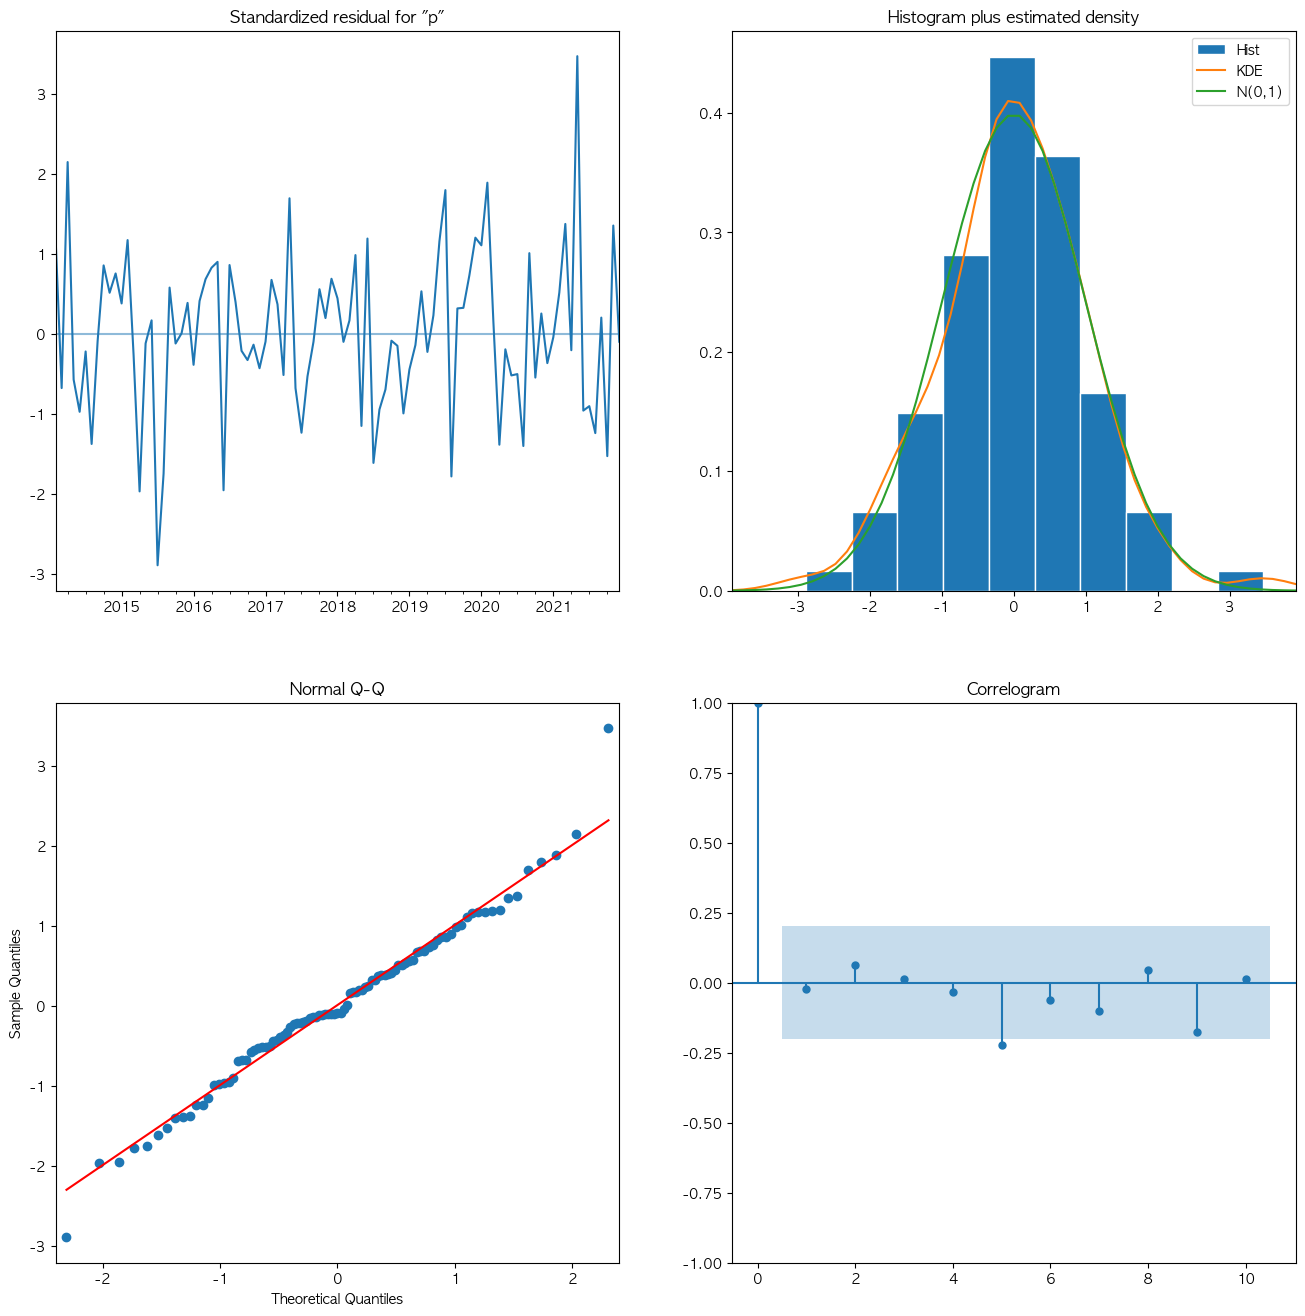

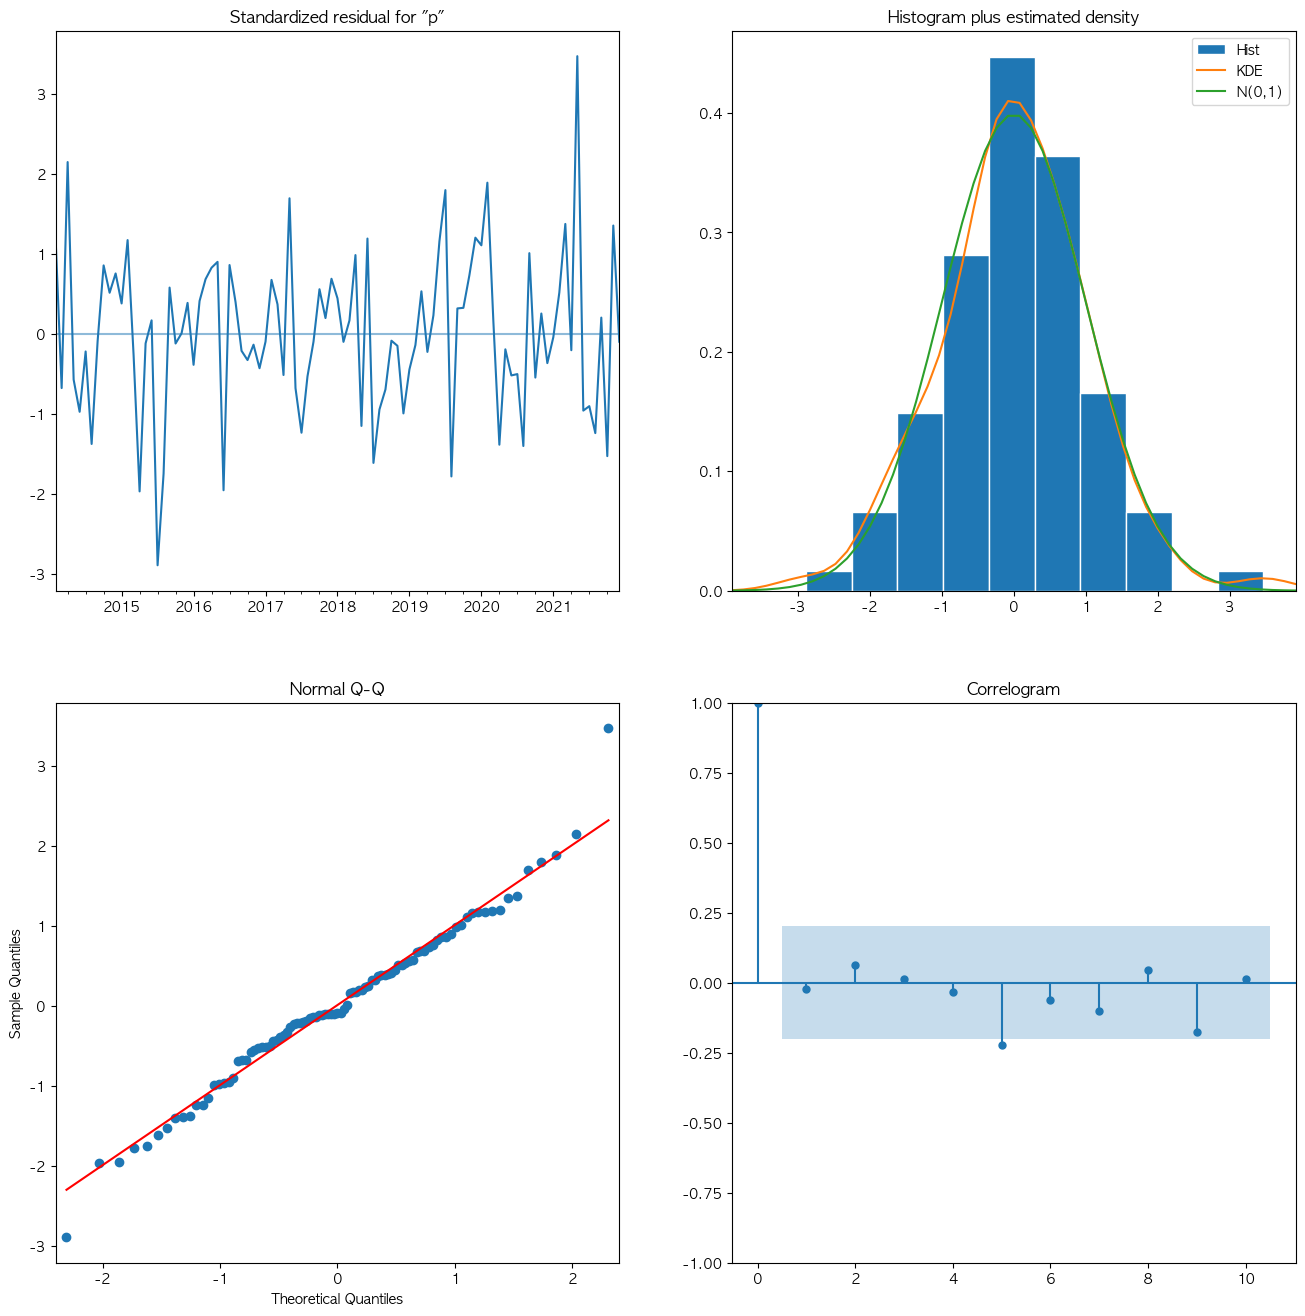

In [ ]:
result.plot_diagnostics(figsize=(16, 16))

In [ ]:
forecast_values = result.get_forecast(steps=7)

In [ ]:
forecast_ci = forecast_values.conf_int()

In [ ]:
forecast_values.summary_frame()

price,mean,mean_se,mean_ci_lower,mean_ci_upper
2022-01-01,3467.754462,192.910952,3089.655944,3845.852980
2022-02-01,3513.356572,272.817285,2978.644520,4048.068625
2022-03-01,3581.393946,334.131570,2926.508102,4236.279789
2022-04-01,3555.788483,385.821904,2799.591446,4311.985519
2022-05-01,3716.980969,431.362002,2871.526980,4562.434958
2022-06-01,3669.671828,472.533398,2743.523386,4595.820270
2022-07-01,3625.045164,510.394404,2624.690514,4625.399814


In [ ]:
pred=[3467.754462, 3513.356572, 3581.393946, 3555.788483, 3716.980969, 3669.671828, 3625.045164]

In [ ]:
target=[3494.000000, 3739.000000, 3858.000000, 4542.540984, 5205.000000, 4778.000000, 3805.000000]

In [ ]:
a=np.array(pred) - np.array(target)

In [ ]:
a

array([  -26.245538,  -225.643428,  -276.606054,  -986.752501,
       -1488.019031, -1108.328172,  -179.954836])

In [ ]:
np.sqrt(sum((a/7)*(a/7))/7)

115.51344258944295

In [ ]:
np.sqrt(sum((a/target)*(a/target))/7)

0.16638970457167282

In [ ]:
100*(sum(np.abs(a/target)))

92.19235414400767

In [ ]:
92.19235414400767/7

13.17033630628681

In [ ]:
mp=[3445.13, 3479.94, 3529.28, 3596.9, 3666.03, 3741.6, 3824.4]


In [ ]:
m=np.array(mp) - np.array(target)

In [ ]:
np.sqrt(sum((m/7)*(m/7))/7)

114.7277681662026

In [ ]:
np.sqrt(sum((m/target)*(m/target))/7)

0.16479014799563704

In [ ]:
100*(sum(np.abs(m/target)))

89.43328277102923

In [ ]:
89.43328277102923/7

12.776183253004175

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(pred, y_test))
print(classification_report(grid_search.predict(X_test), y_test))

In [ ]:
np.sqrt(sum((m/target)*(m/target))/7)

0.16479014799563704

In [ ]:
np.dot(m, m.T)

4514724.050420488

In [ ]:
np.sqrt(4514724.050420488/7)

803.094377163418

In [ ]:
np.sqrt(np.dot(a, a.T)/7)

808.5940981261006

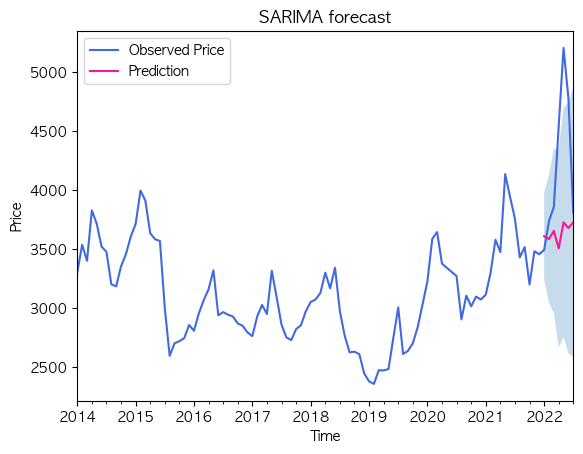

In [ ]:
ax = tot.plot(color='royalblue', label='Observed Price')
#Plot the forecasted values

forecast_values.predicted_mean.plot(ax=ax, label='Prediction', color='deeppink') #Plot the Confidence Intervals
ax.fill_between(forecast_ci. index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],alpha=0.25)


# Axes labels and Title
ax.set_xlabel ('Time')
ax.set_ylabel ('Price')
ax.set_title('SARIMA forecast') #Legneds
plt.legend()

In [ ]:
tot=ar['price'].append(test['0'])

In [ ]:
forecast = result.forecast(steps=7, type='levels')

In [ ]:
forecast

2022-01-01    3494.688426
2022-02-01    3312.159853
2022-03-01    3345.344820
2022-04-01    3409.996790
2022-05-01    3497.435751
2022-06-01    3466.070535
2022-07-01    3573.107815
Freq: MS, Name: predicted_mean, dtype: float64

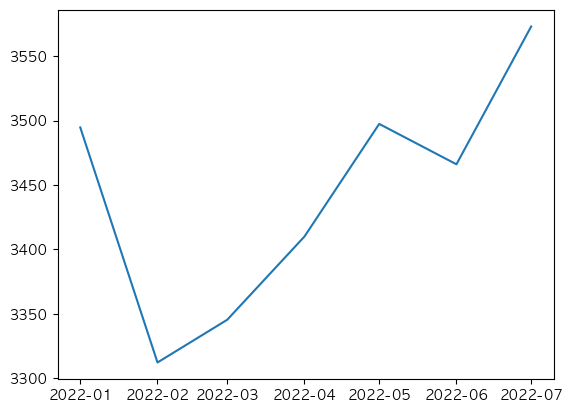

In [ ]:
plt.plot(forecast, label='pred')

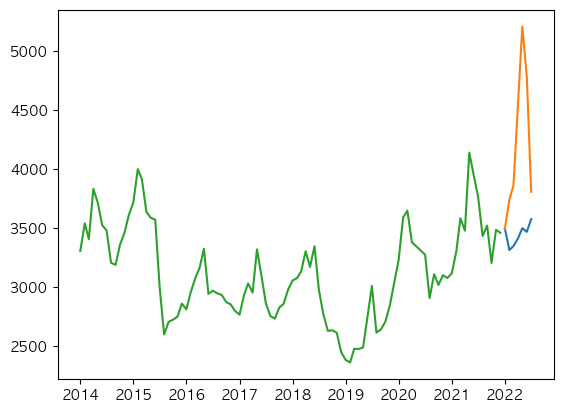

In [ ]:
plt.plot(forecast, label='pred')
plt.plot(test['0'], label='pred')
plt.plot(price['price'], label='pred')

In [ ]:
price

,Unnamed: 0.2,Unnamed: 0.1,price,m,평균수온,평균유의파고,dwh,dwt,t
Unnamed: 0,,,,,,,,,
2014-01-01,0,0,3304.0,2013-07,22.339106,0.616945,0,1,1
2014-02-01,1,1,3538.0,2013-08,25.981856,0.484298,1,1,2
2014-03-01,2,2,3403.0,2013-09,24.440275,0.551663,0,1,3
2014-04-01,3,3,3830.0,2013-10,21.566088,0.754446,1,0,4
2014-05-01,4,4,3716.0,2013-11,17.145869,0.744601,1,0,5
...,...,...,...,...,...,...,...,...,...
2021-08-01,91,91,3431.0,2021-02,9.619111,0.700581,0,1,92
2021-09-01,92,92,3519.0,2021-03,10.660740,0.584154,0,1,93
2021-10-01,93,93,3202.0,2021-04,12.963092,0.567423,0,0,94


In [ ]:
res = sm.tsa.statespace.SARIMAX(price['price'],
                                orde=(0, 1, 0),
                               sesonal_order=(0, 0, 1, 9),
                               enforce_stationarity=True,
                               enforce_invertibility=True).fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            2     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  6.73684D+00    |proj g|=  1.13260D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    2      3      4      1     0     0   2.724D-06   6.737D+00
  F =   6.7367277562370456     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


 This problem is unconstrained.


In [ ]:
price=price.set_index('Unnamed: 0')

KeyError: "None of ['Unnamed: 0'] are in the columns"

In [ ]:
price.index = pd.to_datetime(price.index)

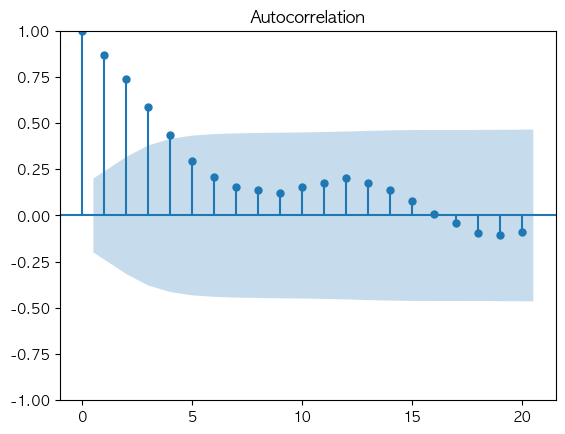

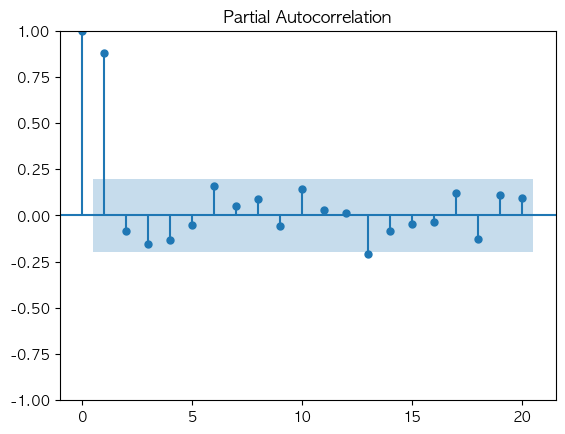

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(price['price'])
plot_pacf(price['price'])
plt.show()

In [ ]:
df['lprice'] = np.log(df['price'])

In [ ]:
from statsmodels.formula.api import ols

In [ ]:
model = ols('lprice ~ t + t^2 + dwh + dwt', df)

In [ ]:
model.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lprice   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.5175
Date:                Sun, 04 Dec 2022   Prob (F-statistic):              0.723
Time:                        02:53:13   Log-Likelihood:                 64.032
No. Observations:                  96   AIC:                            -118.1
Df Residuals:                      91   BIC:                            -105.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.0658      0.035    230.219      0.000       7.996       8.135
t              0.0047      0.007      0.717      0.475      -0.008       0.018
t ^ 2         -0.0051      0.007     -0.771      0.442      -0.018       0.008
dwh            0.0031      0.029      0.107      0.915      -0.054       0.060
dwt           -0.0273      0.027     -1.008      0.316      -0.081       0.027
==============================================================================
Omnibus:                        2.517   Durbin-Watson:                   0.240
Prob(Omnibus):                  0.284   Jarque-Bera (JB):                1.669
Skew:                           0.064   Prob(JB):                        0.434
Kurtosis:                       2.367   Cond. No.                         260.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
price.describe()

,Unnamed: 0.2,Unnamed: 0.1,price,평균수온,평균유의파고,dwh,dwt,t,i
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,0.0
mean,47.500000,47.500000,3121.336236,16.357438,0.604212,0.375000,0.458333,48.500000,NaN
std,27.856777,27.856777,395.138353,5.313179,0.115189,0.486664,0.500876,27.856777,NaN
min,0.000000,0.000000,2360.000000,7.384626,0.380778,0.000000,0.000000,1.000000,NaN
25%,23.750000,23.750000,2836.000000,11.430087,0.505919,0.000000,0.000000,24.750000,NaN
50%,47.500000,47.500000,3075.000000,15.850168,0.591242,0.000000,0.000000,48.500000,NaN
75%,71.250000,71.250000,3410.000000,21.075667,0.696370,1.000000,1.000000,72.250000,NaN
max,95.000000,95.000000,4137.000000,26.088286,0.890521,1.000000,1.000000,96.000000,NaN


In [ ]:
i_tr.describe()

,0
count,96.000000
mean,1.380208
std,0.546495
min,0.500000
25%,1.250000
50%,1.500000
75%,1.750000
max,2.500000


In [ ]:
price['i']=i_tr[0]

In [ ]:
i_tr[0]=i_tr[0].astype(float)